# Formative Assignment: Advanced Linear Algebra (PCA)

**Group:** PCA Pair Team 15: Teta Butera Nelly and Mutoni Keira
**GitHub repo:** [github.com/nellybutera/pca-african-energy-systems](https://github.com/nellybutera/pca-african-energy-systems)
**Topic:** What drives differences in energy systems across 54 African countries, 2000-2022?

**Dataset:** [Our World in Data energy dataset](https://github.com/owid/energy-data) (`owid-energy-data.csv`), filtered to the 54 African countries, 2000-2022. The raw file has real blank cells (GDP, oil, gas and coal production). It has text columns (`country`, `iso_code`). We add one more, `sub_region`, from the UN geoscheme.

**Libraries:** only `numpy` and `matplotlib`. The standard-library modules `os`, `urllib` and `time` are used only to download the file and time the benchmarks. No `pandas`, `sklearn` or `scipy`.

## Part A. Data handling
Steps: load the raw file, keep African rows, find the missing values, impute them, encode the text columns, and fix skewed columns.

In [1]:
import os, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
DATA_PATH = "data/owid-energy-data.csv"
# pinned to the exact OWID commit we used, so a re-run in Colab gives the same numbers
URL = "https://raw.githubusercontent.com/owid/energy-data/7e387a16f70a510e433f8aac7efeac6faa1e5059/owid-energy-data.csv"
if not os.path.exists(DATA_PATH):            # Colab: fetch the raw file if the repo copy is not mounted
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(URL, DATA_PATH)

FEATURES = ["gdp", "population", "primary_energy_consumption", "energy_per_capita", "electricity_demand",
            "per_capita_electricity", "fossil_share_elec", "renewables_share_elec", "hydro_share_elec",
            "solar_share_elec", "oil_production", "gas_production", "coal_production",
            "greenhouse_gas_emissions", "net_elec_imports_share_demand"]
TEXT_COLS = ["country", "iso_code"]

# read only the columns we need (the raw file has 130 columns)
header = open(DATA_PATH, encoding="utf-8").readline().strip().split(",")
wanted = TEXT_COLS + ["year"] + FEATURES
raw = np.loadtxt(DATA_PATH, dtype=str, delimiter=",", comments=None, quotechar='"', encoding="utf-8",
                 skiprows=1, usecols=[header.index(c) for c in wanted])
print("Raw rows x selected columns:", raw.shape, "(raw file has", len(header), "columns)")
raw[:3]

Raw rows x selected columns: (23377, 18) (raw file has 130 columns)


array([['ASEAN (Ember)', '', '2000', '', '', '', '', '378.760', '',
        '80.666', '19.334', '13.314', '0.000', '', '', '', '216.870', ''],
       ['ASEAN (Ember)', '', '2001', '', '', '', '', '405.090', '',
        '80.945', '19.055', '13.412', '0.000', '', '', '', '231.010', ''],
       ['ASEAN (Ember)', '', '2002', '', '', '', '', '433.190', '',
        '82.333', '17.667', '12.304', '0.000', '', '', '', '248.080', '']],
      dtype='<U37')

In [2]:
AFRICA = ("DZA AGO BEN BWA BFA BDI CPV CMR CAF TCD COM COD COG CIV DJI EGY GNQ ERI SWZ ETH GAB GMB GHA GIN GNB KEN "
          "LSO LBR LBY MDG MWI MLI MRT MUS MAR MOZ NAM NER NGA RWA STP SEN SYC SLE SOM ZAF SSD SDN TZA TGO TUN UGA ZMB ZWE").split()
SUBREGION = {}
for r, codes in {
    "North":    "DZA EGY LBY MAR SDN TUN",
    "West":     "BEN BFA CPV CIV GMB GHA GIN GNB LBR MLI MRT NER NGA SEN SLE TGO",
    "East":     "BDI COM DJI ERI ETH KEN MDG MWI MUS MOZ RWA SYC SOM SSD TZA UGA ZMB ZWE",
    "Central":  "AGO CMR CAF TCD COD COG GNQ GAB STP",
    "Southern": "BWA SWZ LSO NAM ZAF"}.items():
    for c in codes.split():
        SUBREGION[c] = r
assert set(SUBREGION) == set(AFRICA) and len(AFRICA) == 54

year_all = raw[:, 2].astype(int)
keep = np.isin(raw[:, 1], AFRICA) & (year_all >= 2000) & (year_all <= 2022)
rows = raw[keep]
country, iso, year = rows[:, 0], rows[:, 1], rows[:, 2].astype(int)
region = np.array([SUBREGION[c] for c in iso])                # new text column added by us
X_raw = np.where(rows[:, 3:] == "", "nan", rows[:, 3:]).astype(float)   # blank cell -> NaN
print("African country-years:", X_raw.shape[0], "| countries:", len(np.unique(country)), "| numeric features:", X_raw.shape[1])

African country-years: 1230 | countries: 54 | numeric features: 15


feature                            missing       %
gdp                                     80     6.5
population                               0     0.0
primary_energy_consumption               0     0.0
energy_per_capita                        0     0.0
electricity_demand                       0     0.0
per_capita_electricity                   0     0.0
fossil_share_elec                        0     0.0
renewables_share_elec                    0     0.0
hydro_share_elec                         0     0.0
solar_share_elec                         0     0.0
oil_production                         252    20.5
gas_production                         300    24.4
coal_production                        312    25.4
greenhouse_gas_emissions                 0     0.0
net_elec_imports_share_demand            0     0.0

Total missing cells: 944 of 18450 (5.1%)


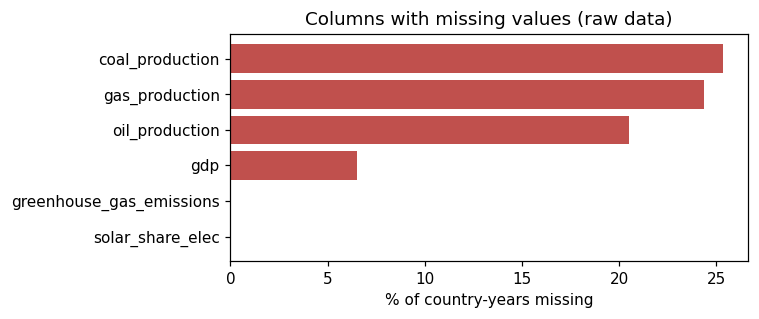

In [3]:
# Which cells are actually missing in the raw data?
n = X_raw.shape[0]
miss_count = np.isnan(X_raw).sum(axis=0)
print(f"{'feature':34s}{'missing':>8s}{'%':>8s}")
for f, m in zip(FEATURES, miss_count):
    print(f"{f:34s}{m:8d}{100*m/n:8.1f}")
print("\nTotal missing cells:", int(miss_count.sum()), "of", X_raw.size, f"({100*miss_count.sum()/X_raw.size:.1f}%)")

order = np.argsort(miss_count)[::-1][:6]
plt.figure(figsize=(7, 3))
plt.barh([FEATURES[i] for i in order][::-1], (100 * miss_count[order] / n)[::-1], color="#c0504d")
plt.xlabel("% of country-years missing"); plt.title("Columns with missing values (raw data)")
plt.tight_layout(); plt.show()

In [4]:
# Which columns are NOT numeric?
for name, arr in [("country", country), ("iso_code", iso), ("sub_region (added)", region)]:
    print(f"{name:20s} text column, {len(np.unique(arr))} distinct values, e.g. {np.unique(arr)[:4].tolist()}")

country              text column, 54 distinct values, e.g. ['Algeria', 'Angola', 'Benin', 'Botswana']
iso_code             text column, 54 distinct values, e.g. ['AGO', 'BDI', 'BEN', 'BFA']
sub_region (added)   text column, 5 distinct values, e.g. ['Central', 'East', 'North', 'Southern']


**Why this imputation.** The blank oil, gas and coal cells sit inside a country's own time series (each of those countries has other years with values), so we fill them from that country's own years: linear in time, and the nearest observed value at the ends. A country's production changes slowly, so this is closer to the truth than one continent-wide average. GDP is different. Eritrea, Somalia, South Sudan and Sudan have no GDP value in any year, so there is nothing to interpolate from. For those four we use the median GDP of their sub-region. This is the weakest step in the notebook: it is a rough estimate and hides real differences inside a sub-region (Sudan is placed with the wealthier North African economies, for example).

In [5]:
def impute_column(col, countries, regions, years):
    """Stage 1: fill a country's gaps from that country's own other years (linear in time, nearest value at the ends).
       Stage 2: if a country has no data at all in this column, use the median of its sub-region."""
    col = col.copy(); s1 = s2 = 0
    for c in np.unique(countries):
        idx = np.where(countries == c)[0]
        idx = idx[np.argsort(years[idx])]
        v = col[idx]; ok = ~np.isnan(v)
        if ok.any() and not ok.all():
            filled = np.interp(years[idx], years[idx][ok], v[ok])
            col[idx[~ok]] = filled[~ok]; s1 += int((~ok).sum())
    for r in np.unique(regions):
        m = regions == r; miss = m & np.isnan(col)
        if miss.any():
            med = np.nanmedian(col[m])
            col[miss] = med if not np.isnan(med) else np.nanmedian(col)
            s2 += int(miss.sum())
    return col, s1, s2

X_imp = X_raw.copy()
print(f"{'feature':34s}{'own-country':>12s}{'sub-region':>12s}")
for j, f in enumerate(FEATURES):
    if np.isnan(X_raw[:, j]).any():
        X_imp[:, j], s1, s2 = impute_column(X_raw[:, j], country, region, year)
        print(f"{f:34s}{s1:12d}{s2:12d}")
print("\nNaN left after imputation:", int(np.isnan(X_imp).sum()))
no_gdp = [str(u) for u in np.unique(country) if np.isnan(X_raw[country == u, 0]).all()]
print("Countries with NO GDP value in any year (filled from their sub-region median):", no_gdp)

feature                            own-country  sub-region
gdp                                          0          80
oil_production                             252           0
gas_production                             300           0
coal_production                            312           0

NaN left after imputation: 0
Countries with NO GDP value in any year (filled from their sub-region median): ['Eritrea', 'Somalia', 'South Sudan', 'Sudan']


In [6]:
# Encoding the text columns
# 1) country -> integer id (kept only as a label; a country id has no numeric meaning, so it is NOT a PCA feature)
countries_sorted, country_id = np.unique(country, return_inverse=True)
# 2) sub_region -> one-hot, dropping the first category to avoid perfectly collinear columns
REGIONS = ["Central", "East", "North", "Southern", "West"]
onehot = np.stack([(region == r).astype(float) for r in REGIONS[1:]], axis=1)
ONEHOT_NAMES = [f"region_{r}" for r in REGIONS[1:]]
print("One-hot columns:", ONEHOT_NAMES, "| reference category:", REGIONS[0])
print("Rows per sub-region:", {r: int((region == r).sum()) for r in REGIONS})

One-hot columns: ['region_East', 'region_North', 'region_Southern', 'region_West'] | reference category: Central
Rows per sub-region: {'Central': 207, 'East': 402, 'North': 138, 'Southern': 115, 'West': 368}


In [7]:
# Skewed columns: GDP, population and fuel production are dominated by a few giants (Nigeria, Egypt, South Africa...)
def skewness(x):
    z = (x - x.mean(0)) / x.std(0)
    return (z ** 3).mean(0)

sk_before = skewness(X_imp)
to_log = (sk_before > 1) & (X_imp.min(axis=0) >= 0)
X_t = X_imp.copy()
X_t[:, to_log] = np.log1p(X_imp[:, to_log])
sk_after = skewness(X_t)
print(f"{'feature':34s}{'skew before':>12s}{'skew after':>12s}  log1p?")
for j, f in enumerate(FEATURES):
    print(f"{f:34s}{sk_before[j]:12.2f}{sk_after[j]:12.2f}  {'yes' if to_log[j] else ''}")

ALL_FEATURES = FEATURES + ONEHOT_NAMES
data = np.hstack([X_t, onehot])                       # final numeric matrix
print("\nFinal matrix:", data.shape, "->", data.shape[0], "country-years x", data.shape[1], "features")

feature                            skew before  skew after  log1p?
gdp                                       3.82        0.12  yes
population                                3.22       -0.56  yes
primary_energy_consumption                4.32        0.78  yes
energy_per_capita                         3.00        0.39  yes
electricity_demand                        4.92        1.21  yes
per_capita_electricity                    3.00        0.16  yes
fossil_share_elec                        -0.43       -0.43  
renewables_share_elec                     0.43        0.43  
hydro_share_elec                          0.54        0.54  
solar_share_elec                          7.75        2.76  yes
oil_production                            3.37        1.21  yes
gas_production                            4.72        1.94  yes
coal_production                           7.12        4.63  yes
greenhouse_gas_emissions                  5.49        2.13  yes
net_elec_imports_share_demand             0.79

## Part B. PCA from scratch (Task 1)

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

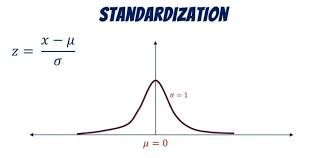

In [8]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mu = np.mean(data, axis=0)
sigma = np.std(data, axis=0)
standardized_data = (data - mu) / sigma
print("column means (should be ~0):", np.round(standardized_data.mean(axis=0)[:5], 10), "...")
print("column std   (should be 1): ", np.round(standardized_data.std(axis=0)[:5], 10), "...")
standardized_data[:5]  # Display the first few rows of standardized data

column means (should be ~0): [-0. -0.  0.  0.  0.] ...
column std   (should be 1):  [1. 1. 1. 1. 1.] ...


array([[ 1.33421548,  0.84842505,  1.79470276,  1.21015022,  1.45185739,
         0.93515947,  1.06141604, -1.05640055, -0.97847175, -0.44374203,
         2.24004044,  3.34533267, -0.29656078,  1.74083898, -0.38650801,
        -0.6967835 ,  2.81301324, -0.32115263, -0.65338668],
       [ 1.37607429,  0.85709383,  1.81694242,  1.22584599,  1.48775507,
         0.95719069,  1.05964929, -1.05463795, -0.97666294, -0.44374203,
         2.23328744,  3.31099135, -0.29656078,  1.77837256, -0.382988  ,
        -0.6967835 ,  2.81301324, -0.32115263, -0.65338668],
       [ 1.43302134,  0.86549158,  1.83894644,  1.24157477,  1.51718423,
         0.97356373,  1.06088066, -1.05586643, -0.97792362, -0.44374203,
         2.26581867,  3.32690581, -0.29656078,  1.80882683, -0.37834798,
        -0.6967835 ,  2.81301324, -0.32115263, -0.65338668],
       [ 1.49917636,  0.87388454,  1.86735634,  1.26466798,  1.56858308,
         1.00931386,  1.04315966, -1.03818704, -0.95978078, -0.44374203,
         2.312

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [9]:
# Step 3: Calculate the Covariance Matrix
n_obs = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / n_obs   # data is already centred; N matches the population sigma used in Step 1
print("shape:", cov_matrix.shape, "| matches np.cov:", np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False, bias=True)))
cov_matrix

shape: (19, 19) | matches np.cov: True


array([[ 1.        ,  0.81939167,  0.9108653 ,  0.23467684,  0.85608532,
         0.34208897, -0.07027882,  0.06519887,  0.06650758,  0.0921966 ,
         0.57181118,  0.61803187,  0.24267185,  0.74996805, -0.1734882 ,
        -0.09904322,  0.5044861 ,  0.00656874, -0.17196145],
       [ 0.81939167,  1.        ,  0.64644497, -0.30043206,  0.63418607,
        -0.12053932, -0.26300494,  0.25937408,  0.29583415,  0.04320798,
         0.32335467,  0.36948645,  0.16988338,  0.46734476, -0.1875351 ,
         0.00589078,  0.25898524, -0.16635699,  0.01696672],
       [ 0.9108653 ,  0.64644497,  1.        ,  0.52813562,  0.95083119,
         0.58342723,  0.04651113, -0.0533331 , -0.0569016 ,  0.05575613,
         0.58039456,  0.72480433,  0.3808739 ,  0.88358522, -0.14363991,
        -0.19160681,  0.56904117,  0.08924343, -0.14482451],
       [ 0.23467684, -0.30043206,  0.52813562,  1.        ,  0.46532712,
         0.86601181,  0.32459057, -0.32864616, -0.37854495,  0.03719389,
         0.353

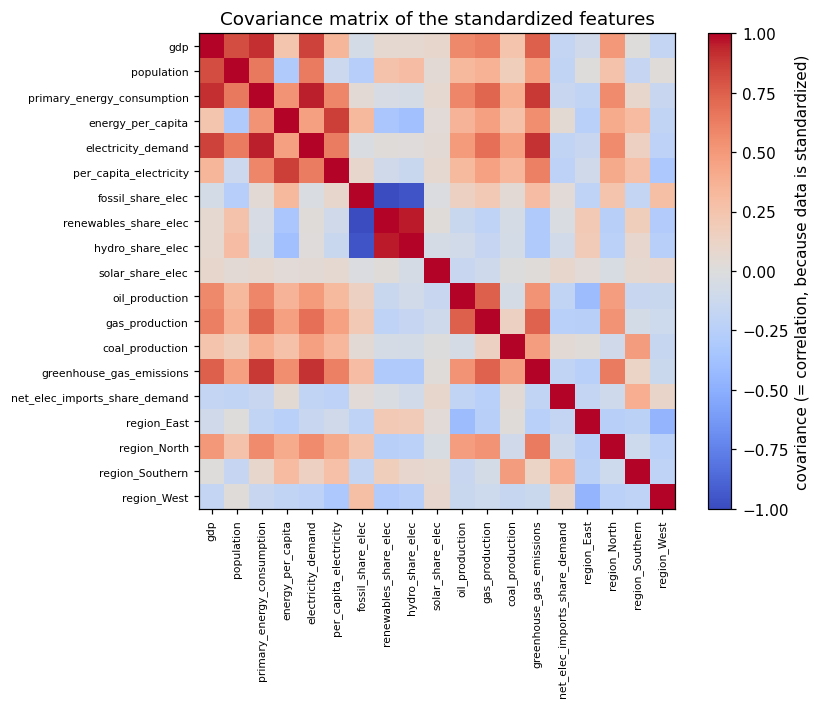

In [10]:
plt.figure(figsize=(8, 6.5))
im = plt.imshow(cov_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(ALL_FEATURES)), ALL_FEATURES, rotation=90, fontsize=7)
plt.yticks(range(len(ALL_FEATURES)), ALL_FEATURES, fontsize=7)
plt.colorbar(im, label="covariance (= correlation, because data is standardized)")
plt.title("Covariance matrix of the standardized features")
plt.tight_layout(); plt.show()

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

PCA uses the covariance matrix to find directions where the data varies most, while its eigenvalues measure how much variance each direction captures. The matrix also reveals features that move together and may contain overlapping information. Here it is only 19 x 19, so it is manageable to decompose.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [11]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)   # eigh: cov_matrix is symmetric, so eigenvalues are real
print("sum of eigenvalues:", round(eigenvalues.sum(), 6), "(= number of features, because the data is standardized:", cov_matrix.shape[0], ")")
print("check C v = lambda v:", np.allclose(cov_matrix @ eigenvectors, eigenvectors * eigenvalues))
eigenvalues, eigenvectors

sum of eigenvalues: 19.0 (= number of features, because the data is standardized: 19 )
check C v = lambda v: True


(array([3.31643111e-05, 9.93419347e-04, 1.40126962e-02, 3.15705976e-02,
        3.90997021e-02, 5.38682089e-02, 8.26736817e-02, 9.71289527e-02,
        2.60953674e-01, 2.74432179e-01, 4.85979707e-01, 5.52477275e-01,
        8.89275023e-01, 1.03715689e+00, 1.36104233e+00, 1.58252451e+00,
        2.23244160e+00, 3.52794407e+00, 6.47639231e+00]),
 array([[ 1.36222616e-03, -2.27121787e-02,  3.46424830e-01,
          6.29813825e-01,  2.04723177e-02,  9.20665554e-02,
          1.79468050e-01, -1.67353449e-01,  2.48476174e-01,
         -3.63915947e-01,  5.23285935e-02, -4.64070172e-02,
         -1.25047148e-01, -5.94284075e-02, -1.14633434e-01,
          1.36063057e-01, -1.45276715e-01, -1.94105884e-01,
         -3.24073015e-01],
        [-3.24209980e-03,  4.95839475e-01, -5.05629729e-01,
         -2.14365431e-01, -3.67130516e-03,  2.30359437e-01,
          2.40833602e-02,  4.19149267e-02,  6.45768171e-02,
         -1.42241867e-01, -2.04633228e-02,  4.06149238e-02,
         -1.02790029e-01,  

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [12]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]                # descending
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
# eigenvectors are only defined up to sign: fix it so the largest-magnitude loading of each PC is positive
signs = np.sign(sorted_eigenvectors[np.abs(sorted_eigenvectors).argmax(axis=0), np.arange(sorted_eigenvectors.shape[1])])
sorted_eigenvectors = sorted_eigenvectors * signs
print("eigenvalues in descending order:", np.all(np.diff(sorted_eigenvalues) <= 0))
print("eigenvectors orthonormal:", np.allclose(sorted_eigenvectors.T @ sorted_eigenvectors, np.eye(len(sorted_eigenvalues))))
sorted_eigenvectors

eigenvalues in descending order: True
eigenvectors orthonormal: True


array([[ 3.24073015e-01, -1.94105884e-01, -1.45276715e-01,
         1.36063057e-01,  1.14633434e-01,  5.94284075e-02,
         1.25047148e-01,  4.64070172e-02,  5.23285935e-02,
        -3.63915947e-01, -2.48476174e-01,  1.67353449e-01,
        -1.79468050e-01, -9.20665554e-02, -2.04723177e-02,
         6.29813825e-01,  3.46424830e-01,  2.27121787e-02,
         1.36222616e-03],
       [ 1.89125314e-01, -3.00920253e-01, -3.21961076e-01,
         2.72825022e-01,  2.25379503e-01, -6.96862346e-02,
         1.02790029e-01, -4.06149238e-02, -2.04633228e-02,
        -1.42241867e-01, -6.45768171e-02, -4.19149267e-02,
        -2.40833602e-02, -2.30359437e-01,  3.67130516e-03,
        -2.14365431e-01, -5.05629729e-01, -4.95839475e-01,
        -3.24209980e-03],
       [ 3.71590451e-01, -1.06171537e-01, -1.35572375e-02,
         1.00314785e-01,  6.48680006e-02,  3.45677456e-02,
         3.08173937e-03, -4.97703345e-02,  2.04105631e-01,
        -1.17021500e-01, -1.13623884e-01,  1.24782536e-01,
    

## Part C. Choosing the number of components (Task 2)
The number of components is chosen from the explained variance, not by hand.

In [13]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative = np.cumsum(explained_variance_ratio)

def choose_k(eigvals_desc, threshold=0.90):
    """Smallest k whose components together explain at least `threshold` of the total variance."""
    cum = np.cumsum(eigvals_desc) / eigvals_desc.sum()
    return int(np.searchsorted(cum, threshold) + 1)

print(f"{'PC':>4s}{'eigenvalue':>12s}{'explained %':>13s}{'cumulative %':>14s}")
for i in range(len(sorted_eigenvalues)):
    print(f"{'PC'+str(i+1):>4s}{sorted_eigenvalues[i]:12.3f}{100*explained_variance_ratio[i]:13.2f}{100*cumulative[i]:14.2f}")

print("\nComponents needed for each variance target:")
for t in (0.70, 0.80, 0.85, 0.90, 0.95, 0.99):
    print(f"  {int(t*100)}% -> k = {choose_k(sorted_eigenvalues, t)}")
print("Kaiser rule (eigenvalue > 1) keeps k =", int((sorted_eigenvalues > 1).sum()))

  PC  eigenvalue  explained %  cumulative %
 PC1       6.476        34.09         34.09
 PC2       3.528        18.57         52.65
 PC3       2.232        11.75         64.40
 PC4       1.583         8.33         72.73
 PC5       1.361         7.16         79.90
 PC6       1.037         5.46         85.36
 PC7       0.889         4.68         90.04
 PC8       0.552         2.91         92.94
 PC9       0.486         2.56         95.50
PC10       0.274         1.44         96.95
PC11       0.261         1.37         98.32
PC12       0.097         0.51         98.83
PC13       0.083         0.44         99.27
PC14       0.054         0.28         99.55
PC15       0.039         0.21         99.75
PC16       0.032         0.17         99.92
PC17       0.014         0.07         99.99
PC18       0.001         0.01        100.00
PC19       0.000         0.00        100.00

Components needed for each variance target:
  70% -> k = 4
  80% -> k = 6
  85% -> k = 6
  90% -> k = 7
  95% -> k = 9


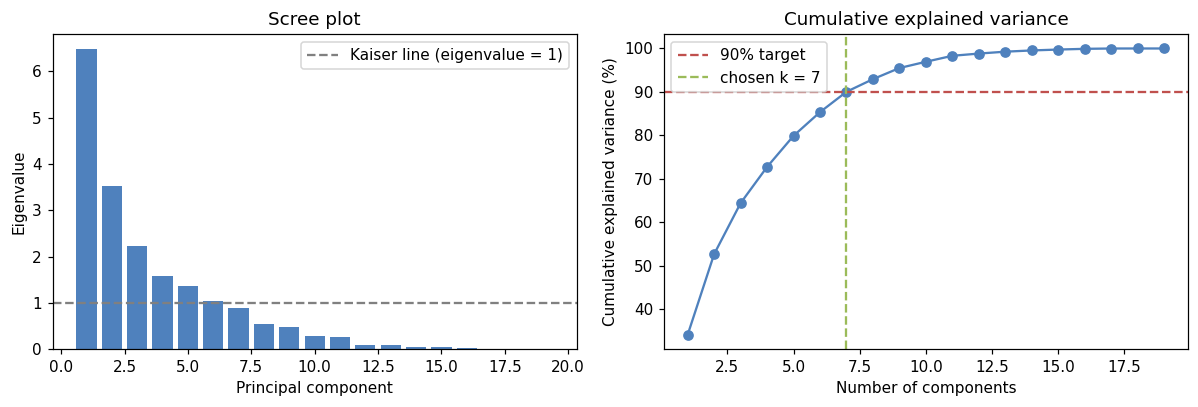

Chosen k = 7: keeps 90.0% of the variance, drops 10.0%


In [14]:
THRESHOLD = 0.90
k = choose_k(sorted_eigenvalues, THRESHOLD)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(range(1, len(sorted_eigenvalues) + 1), sorted_eigenvalues, color="#4f81bd")
ax[0].axhline(1, color="grey", ls="--", label="Kaiser line (eigenvalue = 1)")
ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("Eigenvalue"); ax[0].set_title("Scree plot"); ax[0].legend()
ax[1].plot(range(1, len(cumulative) + 1), 100 * cumulative, "o-", color="#4f81bd")
ax[1].axhline(100 * THRESHOLD, color="#c0504d", ls="--", label=f"{int(THRESHOLD*100)}% target")
ax[1].axvline(k, color="#9bbb59", ls="--", label=f"chosen k = {k}")
ax[1].set_xlabel("Number of components"); ax[1].set_ylabel("Cumulative explained variance (%)")
ax[1].set_title("Cumulative explained variance"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Chosen k = {k}: keeps {100*cumulative[k-1]:.1f}% of the variance, drops {100*(1-cumulative[k-1]):.1f}%")

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [15]:
# Step 6: Project Data onto Principal Components
num_components = choose_k(sorted_eigenvalues, THRESHOLD)   # decided dynamically from explained variance
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]   # project data onto the principal components
reduced_data[:5]

array([[ 5.80009884e+00,  1.11357597e+00, -1.41154618e+00,
        -9.40325263e-01, -1.13725132e+00, -2.25589549e-02,
         1.01521371e+00],
       [ 5.84666602e+00,  1.09743446e+00, -1.39863797e+00,
        -9.29000018e-01, -1.11861655e+00, -1.28776501e-02,
         1.01473908e+00],
       [ 5.91895800e+00,  1.08431473e+00, -1.40515331e+00,
        -9.21541199e-01, -1.12022149e+00, -9.20632158e-03,
         1.01854028e+00],
       [ 6.02197442e+00,  1.04043646e+00, -1.40316895e+00,
        -9.18343548e-01, -1.13680744e+00, -8.89694336e-04,
         1.01055490e+00],
       [ 6.09552843e+00,  1.02828421e+00, -1.39998925e+00,
        -9.12231903e-01, -1.12834731e+00,  5.42741414e-03,
         1.00777929e+00]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [16]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1230, 7)


array([[ 5.80009884e+00,  1.11357597e+00, -1.41154618e+00,
        -9.40325263e-01, -1.13725132e+00, -2.25589549e-02,
         1.01521371e+00],
       [ 5.84666602e+00,  1.09743446e+00, -1.39863797e+00,
        -9.29000018e-01, -1.11861655e+00, -1.28776501e-02,
         1.01473908e+00],
       [ 5.91895800e+00,  1.08431473e+00, -1.40515331e+00,
        -9.21541199e-01, -1.12022149e+00, -9.20632158e-03,
         1.01854028e+00],
       [ 6.02197442e+00,  1.04043646e+00, -1.40316895e+00,
        -9.18343548e-01, -1.13680744e+00, -8.89694336e-04,
         1.01055490e+00],
       [ 6.09552843e+00,  1.02828421e+00, -1.39998925e+00,
        -9.12231903e-01, -1.12834731e+00,  5.42741414e-03,
         1.00777929e+00]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

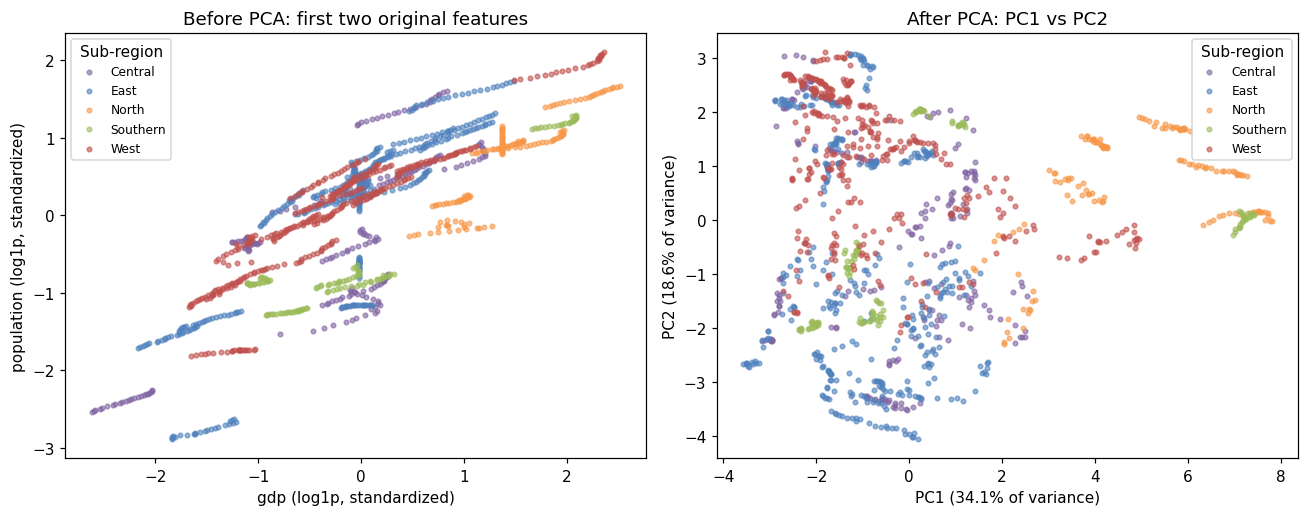

Points before / after: 1230 / 1230
Variance of PC1, PC2: [6.476 3.528] (PC1 must be larger)
Mean of PC1, PC2 (must be ~0, data is centred): [-0.  0.]


In [17]:
# Step 8: Visualize Before and After PCA
colours = {"Central": "#8064a2", "East": "#4f81bd", "North": "#f79646", "Southern": "#9bbb59", "West": "#c0504d"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

# Plot original data (first two features for simplicity)
for r in REGIONS:
    m = region == r
    ax[0].scatter(standardized_data[m, 0], standardized_data[m, 1], s=9, alpha=0.6, c=colours[r], label=r)
lab = lambda j: f"{ALL_FEATURES[j]} ({'log1p, ' if to_log[j] else ''}standardized)"
ax[0].set_xlabel(lab(0)); ax[0].set_ylabel(lab(1))
ax[0].set_title("Before PCA: first two original features"); ax[0].legend(title="Sub-region", fontsize=8)

# Plot reduced data after PCA
for r in REGIONS:
    m = region == r
    ax[1].scatter(reduced_data[m, 0], reduced_data[m, 1], s=9, alpha=0.6, c=colours[r], label=r)
ax[1].set_xlabel(f"PC1 ({100*explained_variance_ratio[0]:.1f}% of variance)")
ax[1].set_ylabel(f"PC2 ({100*explained_variance_ratio[1]:.1f}% of variance)")
ax[1].set_title("After PCA: PC1 vs PC2"); ax[1].legend(title="Sub-region", fontsize=8)
plt.tight_layout(); plt.show()

print("Points before / after:", standardized_data.shape[0], "/", reduced_data.shape[0])
print("Variance of PC1, PC2:", np.round(reduced_data[:, :2].var(axis=0), 3), "(PC1 must be larger)")
print("Mean of PC1, PC2 (must be ~0, data is centred):", np.round(reduced_data[:, :2].mean(axis=0), 10))

PC1 (34.1%): greenhouse_gas_emissions (+0.37), primary_energy_consumption (+0.37), electricity_demand (+0.36), gdp (+0.32), gas_production (+0.32)
PC2 (18.6%): fossil_share_elec (+0.49), renewables_share_elec (-0.49), hydro_share_elec (-0.49), population (-0.30), region_West (+0.20)
PC3 (11.7%): region_Southern (+0.54), coal_production (+0.36), energy_per_capita (+0.35), per_capita_electricity (+0.34), population (-0.32)


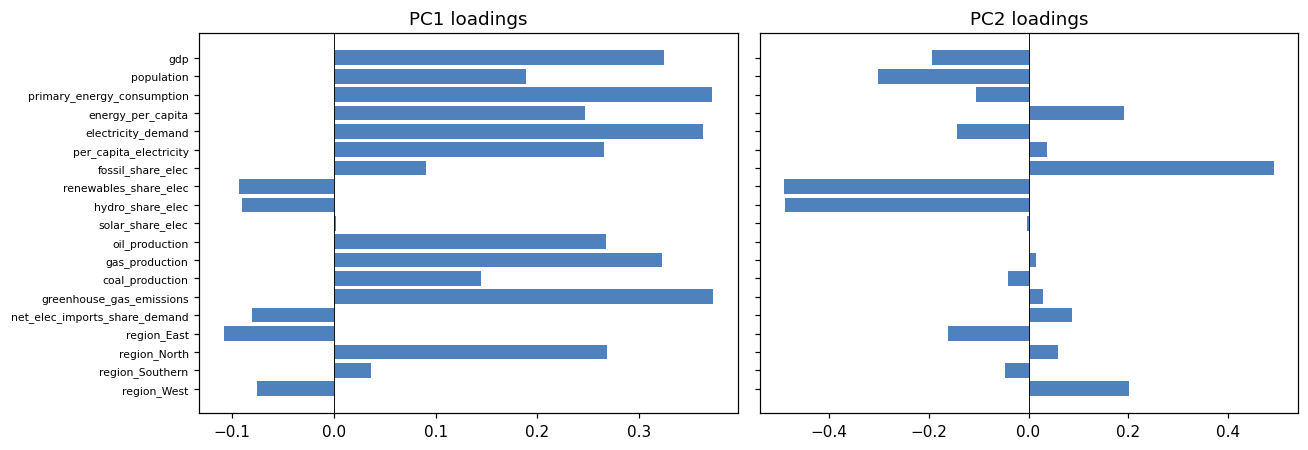

In [18]:
# What do PC1 and PC2 actually measure? Largest loadings (weights) of each component
for p in range(3):
    idx = np.argsort(np.abs(sorted_eigenvectors[:, p]))[::-1][:5]
    print(f"PC{p+1} ({100*explained_variance_ratio[p]:.1f}%): " +
          ", ".join(f"{ALL_FEATURES[i]} ({sorted_eigenvectors[i, p]:+.2f})" for i in idx))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for p in range(2):
    ax[p].barh(ALL_FEATURES[::-1], sorted_eigenvectors[::-1, p], color="#4f81bd")
    ax[p].axvline(0, color="black", lw=0.6); ax[p].set_title(f"PC{p+1} loadings"); ax[p].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()

With k = 7, share of each feature's variance that survives:
  region_North                        74.9%
  gas_production                      75.9%
  oil_production                      76.4%
  region_Southern                     82.4%
  net_elec_imports_share_demand       87.6%
  region_West                         87.8%
  coal_production                     89.1%
  region_East                         89.4%
  energy_per_capita                   91.6%
  gdp                                 92.5%
  solar_share_elec                    92.8%
  per_capita_electricity              93.5%
  greenhouse_gas_emissions            93.7%
  electricity_demand                  95.5%
  primary_energy_consumption          95.7%
  hydro_share_elec                    96.2%
  population                          98.4%
  renewables_share_elec               98.7%
  fossil_share_elec                   98.7%

Overall variance kept: 90.0%


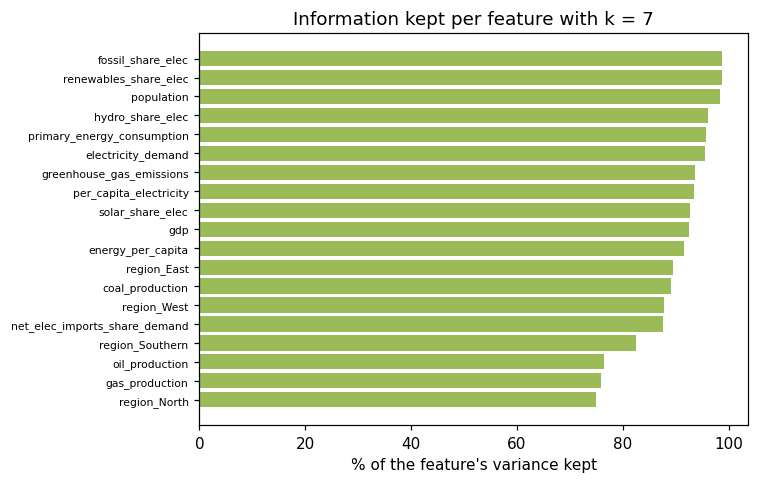

In [19]:
# What is lost? Rebuild the standardized data from only the k kept components and compare
V_k = sorted_eigenvectors[:, :num_components]
reconstructed = reduced_data @ V_k.T
retained = 1 - np.var(standardized_data - reconstructed, axis=0) / np.var(standardized_data, axis=0)   # share of each feature's variance kept
order = np.argsort(retained)
print(f"With k = {num_components}, share of each feature's variance that survives:")
for i in order:
    print(f"  {ALL_FEATURES[i]:34s}{100*retained[i]:6.1f}%")
print(f"\nOverall variance kept: {100*(1-np.sum((standardized_data-reconstructed)**2)/np.sum(standardized_data**2)):.1f}%")

plt.figure(figsize=(7, 4.5))
plt.barh([ALL_FEATURES[i] for i in order], 100 * retained[order], color="#9bbb59")
plt.xlabel("% of the feature's variance kept"); plt.title(f"Information kept per feature with k = {num_components}")
plt.tick_params(axis="y", labelsize=7); plt.tight_layout(); plt.show()

In [20]:
# Sanity check: would we have picked a different k without the log transform?
def pca_eigs(M):
    Z = (M - M.mean(0)) / M.std(0)
    return np.sort(np.linalg.eigvalsh(Z.T @ Z / len(Z)))[::-1]
e_raw = pca_eigs(np.hstack([X_imp, onehot]))
print("PC1 share WITHOUT log transform:", round(100 * e_raw[0] / e_raw.sum(), 1), "%  | k for 90% =", choose_k(e_raw, 0.90))
print("PC1 share WITH log transform:   ", round(100 * explained_variance_ratio[0], 1), "%  | k for 90% =", num_components)

PC1 share WITHOUT log transform: 32.2 %  | k for 90% = 8
PC1 share WITH log transform:    34.1 %  | k for 90% = 7


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

## Interpretation

**1. Before and after visual.** Only two of the 19 features (population and GDP, log-scaled and standardized) are shown on the left, and that gives the appearance of a diagonal trend with regions that overlap, each stripe being a country over the years. The 1,230 points distributed along PC1 and PC2 after PCA, PC1 (34.1% of variance) and PC2 (18.6%) are centred around 0, and more spread out along PC1. Based on the loadings, the overall size of the energy system (PC1) and fossil fuels versus hydro and renewables (PC2) are the factors. The countries of North Africa (in orange) are the furthest right on PC1.

**2. Number of components and trade-off.** We selected the lowest number of components that will capture 90% of the variance (7 90.04%). With Kaiser's rule (eigenvalue > 1) one would remove at 6 and would have 85.4% of the variance, and 4 at 72.7% of the variance. The advantages are we reduce 19 features down to 7, but we sacrifice about 10% of the variance. The eigenvalue of PC7 is already below 1 and adding another component only adds 2.9% to the variance.

**3. Information lost.** With 7 components we retain 90.0% of the variance, meaning only 10% is "fuel-specific detail. Only 76.4% of the variance of oil production, 75.9% of gas production and 74.9% of the North Africa marker remains. The features behind economic activity survive well (GDP 92.5%, energy per capita 91.6%) and population pressure survives best (population 98.4%). So two countries of similar size and electricity mix with different electricity generation from oil and gas would be more similar after PCA. Small differences at the bottom end of GDP should be ignored, as GDP for Eritrea, Somalia, South Sudan and Sudan was filled from sub-region medians.


## Part D. Performance and large datasets (Task 3)
The real dataset is small (about 1,200 rows). To see how the method behaves on large data, we build bigger test sets by resampling our rows and adding a little noise. **These larger sets are synthetic and used only for timing.**

In [21]:
def cov_naive(X):
    """Textbook version with Python loops (slow on purpose, as the baseline)."""
    n, d = X.shape; mu = X.mean(axis=0); C = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            s = 0.0
            for r in range(n):
                s += (X[r, i] - mu[i]) * (X[r, j] - mu[j])
            C[i, j] = s / (n - 1)
    return C

def cov_vectorized(X):
    Xc = X - X.mean(axis=0)
    return (Xc.T @ Xc) / (len(X) - 1)

def cov_chunked(X, chunk=100_000):
    """Streams the data in blocks and merges partial results (Chan et al.), so memory use stays flat."""
    n_tot = 0; mean = np.zeros(X.shape[1]); M2 = np.zeros((X.shape[1], X.shape[1]))
    for s in range(0, len(X), chunk):
        B = X[s:s + chunk].astype(np.float64); nb = len(B)
        mb = B.mean(axis=0); Mb = (B - mb).T @ (B - mb)
        delta = mb - mean; tot = n_tot + nb
        M2 += Mb + np.outer(delta, delta) * n_tot * nb / tot
        mean += delta * nb / tot; n_tot = tot
    return M2 / (n_tot - 1)

def pca_fast(X, k):
    C = cov_vectorized(X)
    vals, vecs = np.linalg.eigh(C)
    o = np.argsort(vals)[::-1]
    return vals[o], vecs[:, o[:k]]

def best_time(f, *a, repeat=3, **kw):
    ts = []
    for _ in range(repeat):
        t = time.perf_counter(); f(*a, **kw); ts.append(time.perf_counter() - t)
    return min(ts)

rng = np.random.default_rng(42)
def make_big(X, n):
    return X[rng.integers(0, len(X), n)] + rng.normal(0, 0.05, (n, X.shape[1]))

# correctness first: all versions must agree
Xb = make_big(standardized_data, 20_000)
print("vectorized == chunked:", np.allclose(cov_vectorized(Xb), cov_chunked(Xb, 4_000)))
print("naive == vectorized (real data):", np.allclose(cov_naive(standardized_data), cov_vectorized(standardized_data)))

vectorized == chunked: True
naive == vectorized (real data): True


In [22]:
# Benchmark 1: loops vs vectorized covariance
print(f"{'rows':>8s}{'naive loops (s)':>18s}{'vectorized (s)':>16s}{'speed-up':>10s}")
for n in (len(standardized_data), 5_000):
    Xn = standardized_data if n == len(standardized_data) else make_big(standardized_data, n)
    tn, tv = best_time(cov_naive, Xn, repeat=1), best_time(cov_vectorized, Xn)
    print(f"{n:8d}{tn:18.4f}{tv:16.6f}{tn/tv:9.0f}x")

    rows   naive loops (s)  vectorized (s)  speed-up
    1230            1.1629        0.000425     2738x
    5000            1.6968        0.000931     1824x


      rows  float64 (s)  float32 (s)  chunked (s)  SVD data (s)  memory f64
      1230       0.0004       0.0003       0.0005        0.0009         0 MB
     10000       0.0027       0.0016       0.0054        0.0111         2 MB
    100000       0.0182       0.0142       0.0343        0.1437        15 MB
   1000000       0.5251       0.1528       0.3129           nan       152 MB


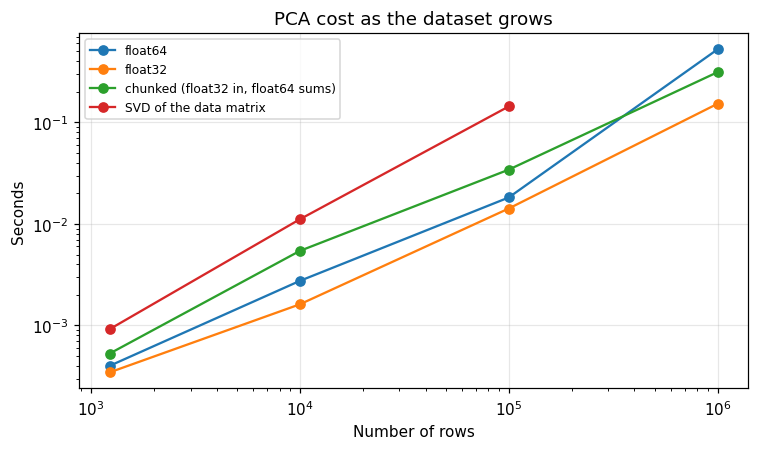

In [23]:
# Benchmark 2: scaling with the number of rows (covariance + eigendecomposition), float64 vs float32 vs chunked
sizes = [1_230, 10_000, 100_000, 1_000_000]
res = {"float64": [], "float32": [], "chunked (float32 in, float64 sums)": [], "SVD of the data matrix": []}
print(f"{'rows':>10s}{'float64 (s)':>13s}{'float32 (s)':>13s}{'chunked (s)':>13s}{'SVD data (s)':>14s}{'memory f64':>12s}")
for n in sizes:
    X64 = make_big(standardized_data, n); X32 = X64.astype(np.float32)
    t64 = best_time(pca_fast, X64, num_components)
    t32 = best_time(pca_fast, X32, num_components)
    tch = best_time(lambda: np.linalg.eigh(cov_chunked(X32, 100_000)))
    tsv = best_time(np.linalg.svd, X64 - X64.mean(0), full_matrices=False, repeat=1) if n <= 100_000 else np.nan
    for key, t in zip(res, (t64, t32, tch, tsv)): res[key].append(t)
    print(f"{n:10d}{t64:13.4f}{t32:13.4f}{tch:13.4f}{tsv:14.4f}{X64.nbytes/1e6:10.0f} MB")
    del X64, X32

plt.figure(figsize=(7, 4.2))
for key, ts in res.items():
    plt.loglog(sizes, ts, "o-", label=key)
plt.xlabel("Number of rows"); plt.ylabel("Seconds"); plt.title("PCA cost as the dataset grows"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [24]:
# Does the cheaper float32 route change the answer? Compare eigenvalues and the chosen k on 1,000,000 rows
Xm = make_big(standardized_data, 1_000_000)
v64, _ = pca_fast(Xm, num_components); v32, _ = pca_fast(Xm.astype(np.float32), num_components)
print("largest eigenvalue difference float64 vs float32:", float(np.max(np.abs(v64 - v32))))
print("k chosen from float64:", choose_k(v64), "| from float32:", choose_k(v32.astype(np.float64)),
      "(these resampled sets carry added noise, so k here can differ from the real data's k =", num_components, ")")
del Xm

largest eigenvalue difference float64 vs float32: 1.501322150682105e-06
k chosen from float64: 8 | from float32: 8 (these resampled sets carry added noise, so k here can differ from the real data's k = 7 )


Timings are from our machine; on Colab the seconds will differ, the ratios should not.
1. Vectorizing the covariance is more than 2,000 times faster than Python loops.
2. Time grows roughly in line with the number of rows. The eigendecomposition itself costs the same at any row count, because the covariance matrix stays 19 x 19.
3. Decomposing the covariance matrix beats an SVD of the whole data matrix (about 7 times faster at 100,000 rows). We skipped the SVD at 1,000,000 rows.
4. float32 took about 35% less time than float64 at 1,000,000 rows. The eigenvalues differ by about 1e-6 and the same k is chosen, so it is safe for this data.
5. The chunked version is slower than the one-shot version but only holds one block in memory at a time, which matters when the data does not fit in RAM.